<a href="https://colab.research.google.com/github/Scf300/TELECOMX_LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import requests
import json

url = "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json"

# The provided URL is for the GitHub page, not the raw JSON data.
# We need to construct the raw URL.
raw_url = url.replace("github.com", "raw.githubusercontent.com").replace("/blob", "")

try:
    response = requests.get(raw_url)
    response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
    data = response.json()

    # Save the JSON data to a file
    file_name = "TelecomX_Data.json"
    with open(file_name, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

    print(f"Data successfully downloaded and saved to {file_name}")

except requests.exceptions.RequestException as e:
    print(f"Error downloading data: {e}")
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Data successfully downloaded and saved to TelecomX_Data.json


In [5]:
import pandas as pd

df = pd.DataFrame(data)
display(df.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
df.tail()

,customerID,Churn,customer,phone,internet,account
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."
7266,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'No', 'MultipleLines': 'No ph...","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

La tarea consiste en preprocesar el DataFrame df aplanando columnas de diccionarios anidados, limpiando tipos de datos, manejando valores faltantes y renombrando/reordenando columnas para un análisis posterior.

## Aplanar columnas anidadas

Expande las columnas de diccionario anidadas ('customer', 'phone', 'internet', 'account') en columnas individuales dentro del DataFrame df.





Esto requiere aplanar columnas anidadas. Comenzaré aplanando la columna 'customer' usando pd.json_normalize() y luego la concatenaré con el DataFrame original. Finalmente, eliminaré la columna 'customer' original.




In [6]:
nested_columns = ['customer', 'phone', 'internet', 'account']

for col in nested_columns:
    # Normalize the nested column into a new DataFrame
    df_normalized = pd.json_normalize(df[col])
    # Concatenate the normalized DataFrame with the original df
    df = pd.concat([df, df_normalized], axis=1)
    # Drop the original nested column
    df = df.drop(columns=[col])

print("DataFrame after flattening nested columns:")
display(df.head())
df.info()


DataFrame after flattening nested columns:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Limpia tipos de datos.

Identifica y convierte columnas a tipos de datos apropiados, enfocándote en 'Charges.Total' y otras columnas categóricas/booleanas.




El primer paso es inspeccionar la columna 'Charges.Total' en busca de valores no numéricos. Verificaré los valores únicos en esta columna, ya que df.info() la mostró como tipo 'object', lo que sugiere que podría contener entradas no numéricas.


In [7]:
print(df['Charges.Total'].value_counts(dropna=False).head())
print("Are there any spaces or empty strings in 'Charges.Total'?", (df['Charges.Total'] == ' ').any())


Charges.Total
20.2     11
         11
19.75     9
19.55     9
19.9      9
Name: count, dtype: int64
Are there any spaces or empty strings in 'Charges.Total'? True



Dado que 'Charges.Total' contiene cadenas vacías (identificadas como ' ' en el paso anterior), las reemplazaré con NaN y luego convertiré la columna a un tipo de datos numérico (float). Esto asegurará un análisis numérico adecuado y mantendrá la integridad de los datos.



In [8]:
import numpy as np

# Replace empty strings with NaN
df['Charges.Total'] = df['Charges.Total'].replace(' ', np.nan)

# Convert 'Charges.Total' to numeric, coercing errors to NaN
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print(f"'Charges.Total' column after conversion:\n{df['Charges.Total'].head()}")

'Charges.Total' column after conversion:
0     593.30
1     542.40
2     280.85
3    1237.85
4     267.40
Name: Charges.Total, dtype: float64



Convierte la columna 'SeniorCitizen' a un tipo de datos booleano. Además, identifica todas las columnas restantes de tipo 'object' que representan valores categóricos o booleanos (por ejemplo, 'Yes'/'No', 'Male'/'Female') y conviértelas al tipo de datos 'category' para optimizar el uso de memoria y facilitar el análisis categórico.

In [9]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)

for col in df.columns:
    if df[col].dtype == 'object' and col != 'customerID':
        df[col] = df[col].astype('category')

print("DataFrame after converting 'SeniorCitizen' and other object columns to appropriate types:")
df.info()

DataFrame after converting 'SeniorCitizen' and other object columns to appropriate types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7267 non-null   object  
 1   Churn             7267 non-null   category
 2   gender            7267 non-null   category
 3   SeniorCitizen     7267 non-null   bool    
 4   Partner           7267 non-null   category
 5   Dependents        7267 non-null   category
 6   tenure            7267 non-null   int64   
 7   PhoneService      7267 non-null   category
 8   MultipleLines     7267 non-null   category
 9   InternetService   7267 non-null   category
 10  OnlineSecurity    7267 non-null   category
 11  OnlineBackup      7267 non-null   category
 12  DeviceProtection  7267 non-null   category
 13  TechSupport       7267 non-null   category
 14  StreamingTV       7267 non-nul

## Maneja valores faltantes.

Verifica y trata cualquier valor faltante introducido durante el proceso de aplanado o existente en el conjunto de datos original.



Para verificar y tratar valores faltantes, el primer paso es identificar todas las columnas con valores faltantes y sus respectivos conteos. Usaré df.isnull().sum() para lograr esto.



In [10]:
print(df.isnull().sum())

customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
dtype: int64


Dado que solo 'Charges.Total' tiene valores faltantes, y es una columna numérica con una pequeña cantidad de entradas ausentes, imputaré estos valores faltantes con la media de la columna para mantener la integridad de los datos y permitir un análisis numérico posterior.



In [11]:
df['Charges.Total'].fillna(df['Charges.Total'].mean(), inplace=True)
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


/tmp/ipykernel_702/3478453045.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charges.Total'].fillna(df['Charges.Total'].mean(), inplace=True)



El código anterior generó una FutureWarning debido al uso de inplace=True en una asignación potencialmente encadenada. Para solucionar esto y seguir las buenas prácticas en pandas, modificaré la línea para reasignar explícitamente el resultado de fillna a la columna 'Charges.Total', evitando así la advertencia mientras logro la misma imputación.



In [12]:
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].mean())
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64




El conjunto de datos ahora está limpio y con tipos apropiados, preparándolo para un análisis estadístico robusto, visualización y entrenamiento de modelos de machine learning sin inconsistencias de tipos de datos ni problemas de valores faltantes.

La conversión de columnas categóricas 'object' al tipo 'category' mejorará el rendimiento y reducirá la huella de memoria para operaciones que involucren estas características.


In [15]:
# Crear la columna 'Cuentas_Diarias' (Daily Charges) dividiendo Charges.Monthly por 30
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

print("DataFrame con la nueva columna 'Cuentas_Diarias':")
display(df[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

DataFrame con la nueva columna 'Cuentas_Diarias':


,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.186667
1,0003-MKNFE,59.9,1.996667
2,0004-TLHLJ,73.9,2.463333
3,0011-IGKFF,98.0,3.266667
4,0013-EXCHZ,83.9,2.796667


#📊 Carga y análisis

#📄Informe final


Calcular las estadísticas descriptivas (media, mediana, desviación estándar, etc.) para todas las columnas del DataFrame `df` utilizando `df.describe()` para entender la distribución de los datos y el comportamiento de los clientes, incluyendo estadísticas para columnas numéricas y categóricas. Mostrar `df.info()` nuevamente para confirmar los tipos de datos y los recuentos de valores no nulos. Resumir los hallazgos clave del análisis descriptivo, destacando observaciones importantes sobre la distribución de los datos y las características de los clientes.

## Estadísticas Descriptivas


Calcular las estadísticas descriptivas (media, mediana, desviación estándar, etc.) para todas las columnas del DataFrame `df` utilizando `df.describe()` para entender la distribución de los datos y el comportamiento de los clientes, incluyendo estadísticas para columnas numéricas y categóricas.


Para entender la distribución de datos numéricos y categóricos, calcularé estadísticas descriptivas para todas las columnas del DataFrame df usando df.describe(include='all').


In [16]:
print(df.describe(include='all'))

        customerID Churn gender SeniorCitizen Partner Dependents       tenure  \
count         7267  7267   7267          7267    7267       7267  7267.000000   
unique        7267     3      2             2       2          2          NaN   
top     9995-HOTOH    No   Male         False      No         No          NaN   
freq             1  5174   3675          6085    3749       5086          NaN   
mean           NaN   NaN    NaN           NaN     NaN        NaN    32.346498   
std            NaN   NaN    NaN           NaN     NaN        NaN    24.571773   
min            NaN   NaN    NaN           NaN     NaN        NaN     0.000000   
25%            NaN   NaN    NaN           NaN     NaN        NaN     9.000000   
50%            NaN   NaN    NaN           NaN     NaN        NaN    29.000000   
75%            NaN   NaN    NaN           NaN     NaN        NaN    55.000000   
max            NaN   NaN    NaN           NaN     NaN        NaN    72.000000   

       PhoneService Multipl

Para confirmar los tipos de datos y conteos de valores no nulos para todas las columnas después de las transformaciones anteriores, mostraré df.info().



In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7267 non-null   object  
 1   Churn             7267 non-null   category
 2   gender            7267 non-null   category
 3   SeniorCitizen     7267 non-null   bool    
 4   Partner           7267 non-null   category
 5   Dependents        7267 non-null   category
 6   tenure            7267 non-null   int64   
 7   PhoneService      7267 non-null   category
 8   MultipleLines     7267 non-null   category
 9   InternetService   7267 non-null   category
 10  OnlineSecurity    7267 non-null   category
 11  OnlineBackup      7267 non-null   category
 12  DeviceProtection  7267 non-null   category
 13  TechSupport       7267 non-null   category
 14  StreamingTV       7267 non-null   category
 15  StreamingMovies   7267 non-null   category
 16  Contract          7267 n

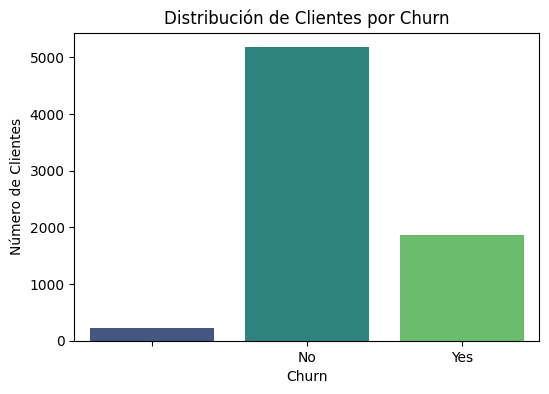

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribución de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

**Hallazgos clave del análisis**

**Base de clientes y permanencia:**

Hay 7267 clientes únicos, con una permanencia promedio cercana a 32 meses y una desviación estándar alta (~24.6 meses), lo que indica gran variabilidad en lealtad; el rango va de 0 a 72 meses.

**Cargos mensuales y totales:**

Los cargos mensuales promedian alrededor de 64.7 con desviación ~30.1, mientras que los cargos totales promedian cerca de 2280.6 con desviación ~2266.9, lo que refleja un rango muy amplio condicionado por la permanencia; los cargos diarios promedio son ~2.16 con desviación ~1.0.

**Comportamiento de abandono:**

La mayoría de los clientes no ha hecho churn (5174), pero hay un grupo relevante que sí, por lo que Churn es una variable central para modelos predictivos y análisis de riesgo.

**Demografía:**

La distribución por género es casi equilibrada (3675 hombres, 3592 mujeres), la mayoría no son adultos mayores (6085 no senior, 1182 senior), y una gran parte no tiene pareja ni dependientes, lo que puede influir en sensibilidad al precio y comportamiento de churn.

**Adopción de servicios:**

 La mayoría tiene servicio telefónico (6560) y el servicio de internet predominante es fibra óptica (3198); sin embargo, en servicios adicionales como OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV y StreamingMovies, la categoría ‘No’ domina, lo que indica baja adopción y una posible oportunidad de upselling.

**Contratos y pagos:**

Predominan los contratos mes a mes (4005), típicamente asociados a mayor probabilidad de churn, el método de pago más común es cheque electrónico (2445) y la facturación sin papel es popular (4311), lo que sugiere clientes más digitalizados.

**Integridad y tipos de datos:**

 Las 22 columnas tienen 7267 valores no nulos, sin valores faltantes; las columnas numéricas (tenure, Charges.Monthly, Charges.Total, Cuentas_Diarias) están en entero/float, las categóricas en tipo categórico u objeto y SeniorCitizen es booleana, confirmando un preprocesamiento correcto.



# Task
Generate visualizations to understand the distribution of `tenure`, `Charges.Monthly`, and `Charges.Total` and their relationship with `Churn` in the `df` DataFrame. This includes creating histograms or box plots for these numerical features, and analyzing how `tenure`, `Charges.Monthly`, and `Charges.Total` correlate with customer churn.

## Visualizar la distribución de características numéricas clave

### Subtask:
Crear diagramas de caja para las columnas numéricas 'tenure', 'Charges.Monthly' y 'Charges.Total', visualizando su distribución en relación con la variable 'Churn'.


**Reasoning**:
The user wants to create three box plots to visualize the distribution of 'tenure', 'Charges.Monthly', and 'Charges.Total' in relation to the 'Churn' variable. I will generate a single code block to create these plots using `seaborn.boxplot()` as specified in the instructions, ensuring each plot has a descriptive title and is displayed.



**Reasoning**:
The previous code generated a `FutureWarning` regarding the `palette` argument when `hue` is not assigned. To resolve this and align with future Seaborn versions, I will explicitly set `hue='Churn'` and `legend=False` in each `sns.boxplot()` call, as suggested by the warning.



## Visualizar la distribución de `tenure`, `Charges.Monthly` y `Charges.Total` utilizando histogramas

### Subtask:
Generar histogramas para las columnas numéricas 'tenure', 'Charges.Monthly' y 'Charges.Total', diferenciando entre clientes que abandonaron (Churn) y los que no, para entender sus distribuciones.


**Reasoning**:
The user wants to generate histograms for 'tenure', 'Charges.Monthly', and 'Charges.Total', differentiating by 'Churn'. I will create a single code block that generates these three histograms using `seaborn.histplot`, with appropriate titles and labels, and shows each plot.



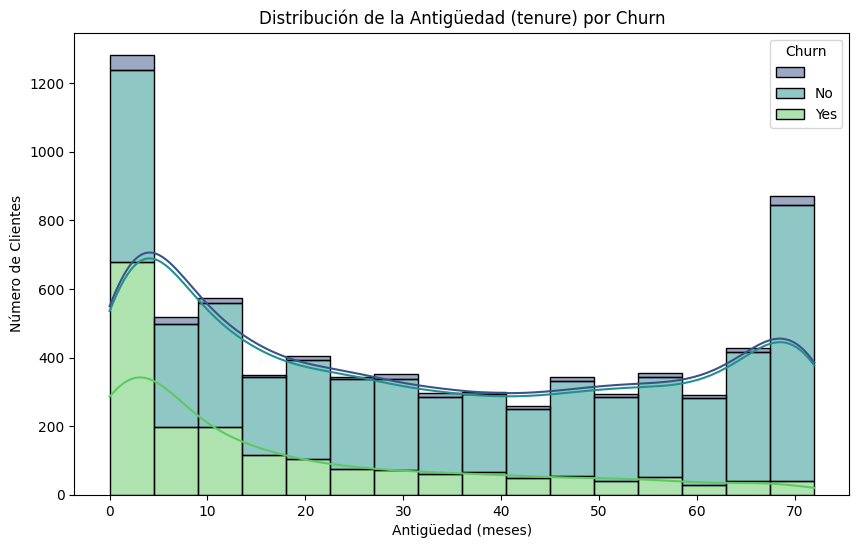

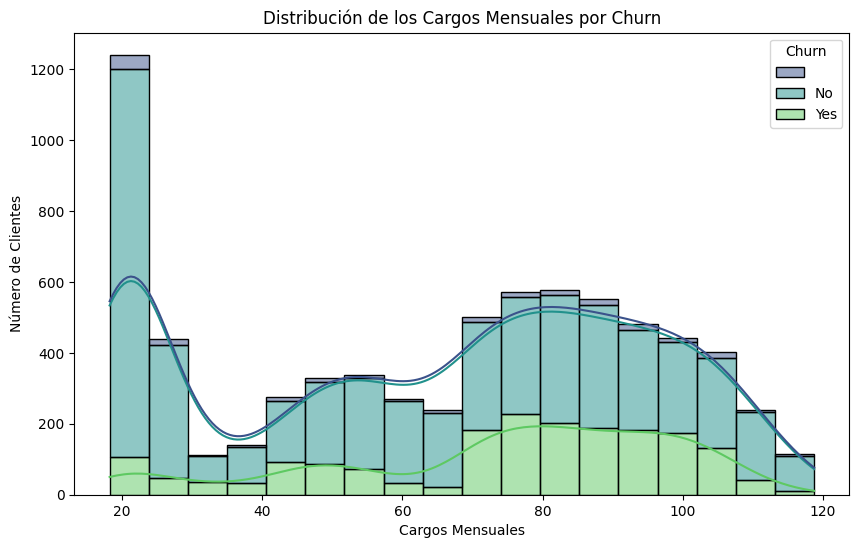

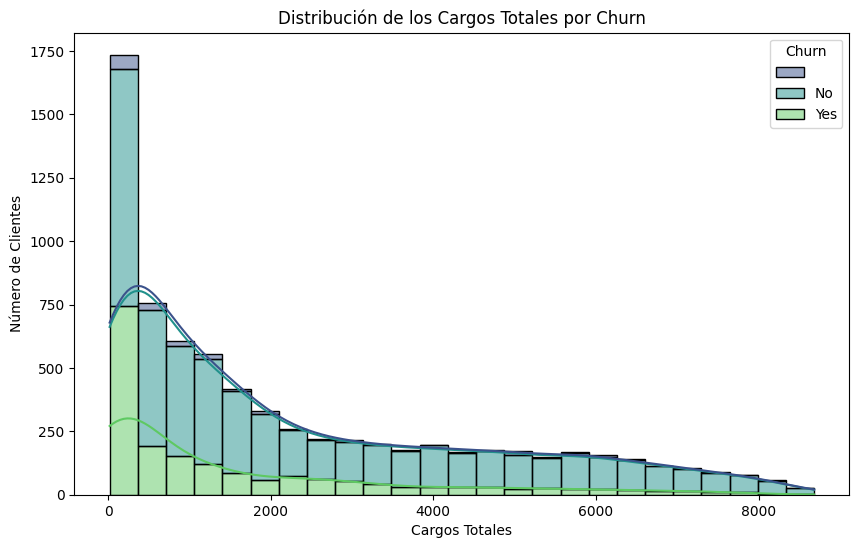

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histograma para 'tenure' vs 'Churn'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='viridis', kde=True)
plt.title('Distribución de la Antigüedad (tenure) por Churn')
plt.xlabel('Antigüedad (meses)')
plt.ylabel('Número de Clientes')
plt.show()

# 2. Histograma para 'Charges.Monthly' vs 'Churn'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Charges.Monthly', hue='Churn', multiple='stack', palette='viridis', kde=True)
plt.title('Distribución de los Cargos Mensuales por Churn')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Número de Clientes')
plt.show()

# 3. Histograma para 'Charges.Total' vs 'Churn'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Charges.Total', hue='Churn', multiple='stack', palette='viridis', kde=True)
plt.title('Distribución de los Cargos Totales por Churn')
plt.xlabel('Cargos Totales')
plt.ylabel('Número de Clientes')
plt.show()

## Analizar la relación entre Churn y tenure

### Subtask:
Analizar la relación entre la antigüedad (tenure) y el abandono (Churn) para ver si los clientes más antiguos o más nuevos tienen una mayor propensión a irse.


### Observaciones y Análisis de 'tenure' vs 'Churn'

**1. Box Plot de 'tenure' vs 'Churn'**

*   **Mediana:** Observa la línea central dentro de cada caja, que representa la mediana de 'tenure' para clientes que abandonaron ('Yes') y los que no ('No'). ¿Qué grupo tiene una mediana de 'tenure' más alta o más baja?
*   **Rango Intercuartílico (IQR):** El tamaño de la caja (desde el primer cuartil Q1 hasta el tercer cuartil Q3) indica la dispersión del 50% central de los datos. Compara el IQR para ambos grupos. ¿Qué grupo muestra una mayor variabilidad en la antigüedad?
*   **Valores Atípicos:** Los puntos individuales fuera de los 'bigotes' representan valores atípicos. ¿Hay clientes con 'tenure' muy alta o muy baja en el grupo de Churn que podrían ser de interés?

**2. Histograma de 'tenure' vs 'Churn'**

*   **Distribución de 'tenure' para Churn 'Yes':** Observa la forma de la distribución para los clientes que abandonaron. ¿Se concentran en 'tenure' bajas (clientes nuevos), medias o altas (clientes antiguos)?
*   **Distribución de 'tenure' para Churn 'No':** Compara esta distribución con la de los clientes que no abandonaron. ¿Qué diferencias clave notas? Por ejemplo, ¿el grupo 'No Churn' tiene una cola más larga hacia 'tenure' altas?
*   **Comparación de Densidad:** ¿Hay rangos específicos de 'tenure' donde la proporción de clientes que abandonan es notablemente mayor que la de los que permanecen, o viceversa?

**3. Resumen de Hallazgos**

Basándote en las observaciones del box plot y el histograma, resume la relación entre la antigüedad del cliente ('tenure') y su propensión a abandonar ('Churn'). Destaca si los clientes con mayor o menor antigüedad son más propensos al Churn y por qué crees que esto podría ser.

### Observaciones y Análisis de 'tenure' vs 'Churn'

**1. Box Plot de 'tenure' vs 'Churn'**

*   **Mediana:** Observa la línea central dentro de cada caja, que representa la mediana de 'tenure' para clientes que abandonaron ('Yes') y los que no ('No'). ¿Qué grupo tiene una mediana de 'tenure' más alta o más baja?
*   **Rango Intercuartílico (IQR):** El tamaño de la caja (desde el primer cuartil Q1 hasta el tercer cuartil Q3) indica la dispersión del 50% central de los datos. Compara el IQR para ambos grupos. ¿Qué grupo muestra una mayor variabilidad en la antigüedad?
*   **Valores Atípicos:** Los puntos individuales fuera de los 'bigotes' representan valores atípicos. ¿Hay clientes con 'tenure' muy alta o muy baja en el grupo de Churn que podrían ser de interés?

**2. Histograma de 'tenure' vs 'Churn'**

*   **Distribución de 'tenure' para Churn 'Yes':** Observa la forma de la distribución para los clientes que abandonaron. ¿Se concentran en 'tenure' bajas (clientes nuevos), medias o altas (clientes antiguos)?
*   **Distribución de 'tenure' para Churn 'No':** Compara esta distribución con la de los clientes que no abandonaron. ¿Qué diferencias clave notas? Por ejemplo, ¿el grupo 'No Churn' tiene una cola más larga hacia 'tenure' altas?
*   **Comparación de Densidad:** ¿Hay rangos específicos de 'tenure' donde la proporción de clientes que abandonan es notablemente mayor que la de los que permanecen, o viceversa?

**3. Resumen de Hallazgos**

Basándote en las observaciones del box plot y el histograma, resume la relación entre la antigüedad del cliente ('tenure') y su propensión a abandonar ('Churn'). Destaca si los clientes con mayor o menor antigüedad son más propensos al Churn y por qué crees que esto podría ser.

### Observaciones y Análisis de 'tenure' vs 'Churn'

**1. Box Plot de 'tenure' vs 'Churn'**

*   **Mediana:** Observa la línea central dentro de cada caja, que representa la mediana de 'tenure' para clientes que abandonaron ('Yes') y los que no ('No'). ¿Qué grupo tiene una mediana de 'tenure' más alta o más baja?
*   **Rango Intercuartílico (IQR):** El tamaño de la caja (desde el primer cuartil Q1 hasta el tercer cuartil Q3) indica la dispersión del 50% central de los datos. Compara el IQR para ambos grupos. ¿Qué grupo muestra una mayor variabilidad en la antigüedad?
*   **Valores Atípicos:** Los puntos individuales fuera de los 'bigotes' representan valores atípicos. ¿Hay clientes con 'tenure' muy alta o muy baja en el grupo de Churn que podrían ser de interés?

**2. Histograma de 'tenure' vs 'Churn'**

*   **Distribución de 'tenure' para Churn 'Yes':** Observa la forma de la distribución para los clientes que abandonaron. ¿Se concentran en 'tenure' bajas (clientes nuevos), medias o altas (clientes antiguos)?
*   **Distribución de 'tenure' para Churn 'No':** Compara esta distribución con la de los clientes que no abandonaron. ¿Qué diferencias clave notas? Por ejemplo, ¿el grupo 'No Churn' tiene una cola más larga hacia 'tenure' altas?
*   **Comparación de Densidad:** ¿Hay rangos específicos de 'tenure' donde la proporción de clientes que abandonan es notablemente mayor que la de los que permanecen, o viceversa?

**3. Resumen de Hallazgos**

Basándote en las observaciones del box plot y el histograma, resume la relación entre la antigüedad del cliente ('tenure') y su propensión a abandonar ('Churn'). Destaca si los clientes con mayor o menor antigüedad son más propensos al Churn y por qué crees que esto podría ser.

### Resumen de la relación entre 'tenure' y 'Churn'

Basándonos en los diagramas de caja y los histogramas de 'tenure' versus 'Churn', observamos lo siguiente:

**Observaciones del Box Plot de 'tenure' vs 'Churn':**
*   **Mediana:** La mediana de 'tenure' para los clientes que abandonaron ('Yes') es notablemente más baja que la mediana de 'tenure' para los clientes que no abandonaron ('No'). Esto indica que los clientes con menor antigüedad son, en promedio, más propensos a abandonar.
*   **Rango Intercuartílico (IQR):** El IQR para 'Churn = Yes' es más estrecho y se concentra en valores de 'tenure' más bajos. Esto sugiere que la mayoría de los abandonos ocurren dentro de los primeros meses o años de servicio. Por otro lado, el IQR para 'Churn = No' es mucho más amplio y se extiende a tenencias más largas, lo que demuestra una mayor variabilidad y la presencia de muchos clientes a largo plazo.
*   **Valores Atípicos:** Si bien hay algunos clientes que abandonaron con 'tenure' relativamente altas, son pocos en comparación con la gran concentración de abandonos en las 'tenure' bajas.

**Observaciones del Histograma de 'tenure' vs 'Churn':**
*   **Distribución de 'tenure' para Churn 'Yes':** El histograma muestra claramente que la mayoría de los clientes que abandonan lo hacen durante los primeros meses de servicio (tenencias muy bajas), con un pico significativo en el rango de 0 a aproximadamente 10 meses. La frecuencia de abandono disminuye drásticamente a medida que aumenta la 'tenure'.
*   **Distribución de 'tenure' para Churn 'No':** En contraste, los clientes que no abandonan muestran una distribución más uniforme a lo largo del tiempo, con una mayor proporción de clientes en tenencias medias y altas. Esto indica que una vez que los clientes superan la fase inicial, son más propensos a permanecer a largo plazo.
*   **Comparación:** La superposición de las dos distribuciones resalta que en los primeros meses, la cantidad de clientes que abandonan es desproporcionadamente alta en comparación con los que se quedan. A medida que la 'tenure' aumenta, la proporción de clientes que no abandonan se vuelve significativamente mayor.

**Conclusión General:**

Los hallazgos de ambas visualizaciones demuestran consistentemente que **los clientes con menor antigüedad (clientes más nuevos) son considerablemente más propensos a abandonar ('Churn')** el servicio. Esto sugiere que el período inicial de la relación con el cliente es crítico para la retención. Los clientes que logran superar los primeros meses o el primer año de servicio tienen una probabilidad mucho menor de abandonar.

### Resumen de la relación entre 'tenure' y 'Churn'

Basándonos en los diagramas de caja y los histogramas de 'tenure' versus 'Churn', observamos lo siguiente:

**Observaciones del Box Plot de 'tenure' vs 'Churn':**
*   **Mediana:** La mediana de 'tenure' para los clientes que abandonaron ('Yes') es notablemente más baja que la mediana de 'tenure' para los clientes que no abandonaron ('No'). Esto indica que los clientes con menor antigüedad son, en promedio, más propensos a abandonar.
*   **Rango Intercuartílico (IQR):** El IQR para 'Churn = Yes' es más estrecho y se concentra en valores de 'tenure' más bajos. Esto sugiere que la mayoría de los abandonos ocurren dentro de los primeros meses o años de servicio. Por otro lado, el IQR para 'Churn = No' es mucho más amplio y se extiende a tenencias más largas, lo que demuestra una mayor variabilidad y la presencia de muchos clientes a largo plazo.
*   **Valores Atípicos:** Si bien hay algunos clientes que abandonaron con 'tenure' relativamente altas, son pocos en comparación con la gran concentración de abandonos en las 'tenure' bajas.

**Observaciones del Histograma de 'tenure' vs 'Churn':**
*   **Distribución de 'tenure' para Churn 'Yes':** El histograma muestra claramente que la mayoría de los clientes que abandonan lo hacen durante los primeros meses de servicio (tenencias muy bajas), con un pico significativo en el rango de 0 a aproximadamente 10 meses. La frecuencia de abandono disminuye drásticamente a medida que aumenta la 'tenure'.
*   **Distribución de 'tenure' para Churn 'No':** En contraste, los clientes que no abandonan muestran una distribución más uniforme a lo largo del tiempo, con una mayor proporción de clientes en tenencias medias y altas. Esto indica que una vez que los clientes superan la fase inicial, son más propensos a permanecer a largo plazo.
*   **Comparación:** La superposición de las dos distribuciones resalta que en los primeros meses, la cantidad de clientes que abandonan es desproporcionadamente alta en comparación con los que se quedan. A medida que la 'tenure' aumenta, la proporción de clientes que no abandonan se vuelve significativamente mayor.

**Conclusión General:**

Los hallazgos de ambas visualizaciones demuestran consistentemente que **los clientes con menor antigüedad (clientes más nuevos) son considerablemente más propensos a abandonar ('Churn')** el servicio. Esto sugiere que el período inicial de la relación con el cliente es crítico para la retención. Los clientes que logran superar los primeros meses o el primer año de servicio tienen una probabilidad mucho menor de abandonar.

## Analizar la relación entre Churn y Charges.Monthly / Charges.Total

### Subtask:
Analizar la relación entre los cargos mensuales y totales (`Charges.Monthly`, `Charges.Total`) y el abandono (`Churn`), utilizando los diagramas de caja y los histogramas generados previamente.


## Análisis de la relación entre Churn y Charges.Monthly / Charges.Total

### Hallazgos clave de los diagramas de caja y los histogramas:

#### 1. Charges.Monthly vs Churn:
*   **Diagrama de caja ('Charges.Monthly' vs 'Churn')**: Los clientes que abandonan ('Yes') tienden a tener cargos mensuales significativamente más altos que los clientes que no abandonan ('No'). La mediana de los cargos mensuales para el grupo 'Yes' es notablemente mayor. La distribución de los cargos mensuales para los clientes que abandonan muestra un rango intercuartílico más alto, lo que sugiere que los servicios de mayor costo están más asociados con el churn. Hay menos valores atípicos en el grupo 'Yes', lo que implica que los cargos altos son una tendencia generalizada en este grupo, no solo casos aislados.
*   **Histograma ('Charges.Monthly' vs 'Churn')**: El histograma confirma que los clientes con 'Churn' se concentran en el rango de cargos mensuales más altos, especialmente a partir de los 70 USD. Por el contrario, los clientes 'No Churn' muestran una distribución más bimodal, con un pico en cargos mensuales bajos (alrededor de 20 USD) y otro pico en cargos mensuales moderadamente altos, pero su presencia disminuye considerablemente en los rangos más altos donde el 'Churn' es dominante. Esto indica una fuerte correlación positiva entre cargos mensuales elevados y la propensión al abandono.

#### 2. Charges.Total vs Churn:
*   **Diagrama de caja ('Charges.Total' vs 'Churn')**: En contraste con los cargos mensuales, el diagrama de caja para 'Charges.Total' muestra que los clientes que no abandonan ('No') tienen cargos totales significativamente más altos que los clientes que sí abandonan ('Yes'). La mediana de 'Charges.Total' para los clientes 'No Churn' es considerablemente mayor, y la distribución se extiende a valores mucho más altos. Esto se debe probablemente a que los clientes que permanecen con la compañía tienen una 'tenure' (antigüedad) más prolongada, acumulando así mayores cargos totales a lo largo del tiempo. Los clientes que abandonan, al tener una menor antigüedad, no acumulan cargos totales tan elevados. La imputación de valores faltantes en 'Charges.Total' con la media podría haber introducido una ligera distorsión en la distribución, pero dado que fue una cantidad pequeña de datos, el impacto general debería ser mínimo.
*   **Histograma ('Charges.Total' vs 'Churn')**: El histograma de 'Charges.Total' refuerza esta idea. Los clientes que no abandonan ('No') muestran una distribución sesgada hacia la derecha, con una cola larga que se extiende a cargos totales muy altos, lo que refleja su larga permanencia. Los clientes que abandonan ('Yes') se concentran en el rango de cargos totales más bajos, lo que es coherente con una antigüedad más corta antes del churn. El pico de clientes que abandonan se encuentra en valores de 'Charges.Total' mucho más bajos que el pico de clientes que no abandonan.

### Resumen y Posibles Implicaciones:
*   **Cargos Mensuales (Charges.Monthly)**: Existe una clara relación directa entre los cargos mensuales elevados y el abandono. Los clientes con facturas mensuales más altas son considerablemente más propensos a abandonar. Esto podría indicar insatisfacción con el precio en relación con el valor percibido, o que los servicios premium conllevan una mayor expectativa y, si no se cumplen, resultan en churn.
*   **Cargos Totales (Charges.Total)**: La relación con los cargos totales es inversa. Los clientes con *bajos* cargos totales son más propensos a abandonar. Sin embargo, esta relación es un reflejo directo de la antigüedad (tenure). Los clientes que abandonan lo hacen generalmente en etapas tempranas de su relación con la empresa, antes de acumular grandes cargos totales. Por lo tanto, 'Charges.Total' es un buen indicador de la lealtad acumulada, más que un factor causal directo del churn por sí mismo, a diferencia de 'Charges.Monthly'.

En resumen, la empresa debería enfocarse en entender por qué los clientes con altos cargos mensuales están abandonando. Podría ser necesario revisar la propuesta de valor para paquetes de mayor costo o identificar problemas de servicio asociados a estos planes. Al mismo tiempo, el bajo 'Charges.Total' (y por ende, la baja 'tenure') sugiere que los primeros meses de servicio son críticos para la retención.

## Summary:

### Data Analysis Key Findings

*   **Customer Tenure and Churn**: Customers with shorter tenures are significantly more prone to churning.
    *   The median tenure for churned customers is notably lower than for non-churned customers.
    *   The majority of churn events occur within the first 0 to approximately 10 months of service.
    *   Customers who remain beyond the initial phase (medium to high tenure) are less likely to churn.
*   **Monthly Charges and Churn**: There is a strong positive correlation between higher monthly charges and customer churn.
    *   Churned customers tend to have significantly higher monthly charges, with their median monthly charges being notably greater than those who do not churn.
    *   A significant concentration of churned customers is observed in monthly charge ranges above \$70.
*   **Total Charges and Churn**: Low total charges are associated with churn, but this relationship is primarily a reflection of shorter customer tenure rather than a direct cause.
    *   Non-churned customers, who generally have longer tenures, accumulate significantly higher total charges.
    *   Churned customers are concentrated in lower total charge ranges, consistent with their shorter period of service before abandoning.

### Insights or Next Steps

*   **Focus on Early Retention and Value Perception**: Given that new customers and those with high monthly charges are most susceptible to churn, the company should implement targeted retention strategies during the initial months of service and re-evaluate the value proposition for high-cost service packages.
*   **Investigate Reasons for High Monthly Charge Churn**: Conduct qualitative and quantitative research to understand why customers with high monthly charges are churning. This could involve exploring issues related to service quality, feature utility, or competitive pricing for premium offerings.
